# 자율이동체시스템 — Mid-term Report

**KITTI Odometry Dataset, Sequence 09 기반**

KITTI odometry sequence 09 데이터를 활용하여:
1. Projection Matrix 해석
2. 3D → 2D 투영 시각화
3. Pose를 이용한 차량 궤적 시각화
4. Bayesian 차선 검출 결과와 Projection Matrix 연계 해석
5. 실패 구간 분석
6. 딥러닝 기반 차선 검출 비교

순서대로 수행하였다.

## 환경 설정 및 경로 초기화

In [88]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import math
import warnings
warnings.filterwarnings('ignore')

# ────────────────────────────────────────────
# 경로 설정
# ────────────────────────────────────────────
IMAGE_DIR  = Path('data_odometry_gray/dataset/sequences/09/image_0')
CALIB_FILE = Path('data_odometry_gray/dataset/sequences/09/calib.txt')
POSE_FILE  = Path('data_odometry_poses/dataset/poses/09.txt')
OUT_DIR    = Path('outputs/midterm_seq09')
OUT_DIR    = Path('outputs/midterm_seq09')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Image dir  : {IMAGE_DIR}')
print(f'Calib file : {CALIB_FILE}')
print(f'Pose  file : {POSE_FILE}')
print(f'Output dir : {OUT_DIR}')


Image dir  : data_odometry_gray\dataset\sequences\09\image_0
Calib file : data_odometry_gray\dataset\sequences\09\calib.txt
Pose  file : data_odometry_poses\dataset\poses\09.txt
Output dir : outputs\midterm_seq09


## 문제 1. Projection Matrix 해석

Projection Matrix는 3D 공간상의 점을 카메라 이미지 평면 위의 2D 픽셀 좌표로 변환하는 행렬이다. 

$P = K [R \mid t]$

여기서 $K$는 카메라 내부 파라미터 행렬이고, $[R \mid t]$는 카메라 외부 파라미터이다.

### 1. Intrinsic 파라미터의 의미

카메라 내부 파라미터 행렬 $K$는 다음과 같다.

$K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}$

| 파라미터 | 의미 |
|---|---|
| $f_x, f_y$ | 픽셀 단위의 초점 거리이다. 각각 이미지의 x축, y축 방향 스케일을 의미한다. |
| $c_x, c_y$ | 주점(principal point)이다. 일반적으로 이미지 중심 근처의 좌표를 의미한다. |

즉, intrinsic 파라미터는 카메라 자체의 특성을 나타내며, 카메라 좌표계의 점을 이미지 픽셀 좌표계로 변환하는 역할을 한다.

### 2. Extrinsic 파라미터의 역할

외부 파라미터 $[R \mid t]$는 3D 월드 좌표계의 점을 카메라 좌표계로 변환하는 역할을 한다.

| 파라미터 | 의미 |
|---|---|
| $R$ | 회전 행렬이다. 월드 좌표계의 방향을 카메라 좌표계의 방향에 맞게 회전시킨다. |
| $t$ | 이동 벡터이다. 월드 좌표계의 원점을 카메라 좌표계 기준으로 이동시킨다. |

따라서 3D 점 $X_w = [X, Y, Z]^T$는 다음과 같이 카메라 좌표계의 점 $X_c$로 변환된다.

$X_c = R X_w + t$

즉, extrinsic 파라미터는 카메라가 3D 공간에서 어디에 위치하고 어떤 방향을 바라보는지를 나타낸다.

### 3. 3D 점을 이미지 좌표로 변환하는 과정

3D 점을 동차좌표로 표현하면 다음과 같다.

$\tilde{X} =
\begin{bmatrix}
X \\
Y \\
Z \\
1
\end{bmatrix}$

이 점에 Projection Matrix $P$를 곱하면 이미지 평면상의 동차좌표가 계산된다.

$$\begin{bmatrix}
\tilde{u}\\
\tilde{v}\\
\tilde{w}
\end{bmatrix}
=
P
\begin{bmatrix}
X\\
Y\\
Z\\
1
\end{bmatrix}$$


여기서 $\tilde{u}$, $\tilde{v}$, $\tilde{w}$는 아직 실제 픽셀 좌표가 아니라 동차좌표이다. 따라서 세 번째 성분 $\tilde{w}$로 나누어 정규화하면 최종 이미지 좌표 $(u, v)$를 얻을 수 있다.

$u = \frac{\tilde{u}}{\tilde{w}}$

$v = \frac{\tilde{v}}{\tilde{w}}$

즉, Projection Matrix $P$는 3D 점의 위치와 깊이 정보를 이용하여 해당 점이 카메라 이미지에서 어느 픽셀 위치에 나타나는지를 계산한다. 이 과정은 원근 투영을 의미하며, 카메라로부터 멀리 있는 점일수록 이미지에서는 더 작게 보이고 소실점 방향으로 모이게 된다.

In [45]:
from pathlib import Path
import numpy as np
import cv2

def load_calib(calib_path: Path) -> dict:
    calib = {}

    with open(calib_path, "r") as f:
        for line in f:
            line = line.strip()

            if not line or ":" not in line:
                continue

            key, vals = line.split(":", 1)
            values = np.array([float(v) for v in vals.split()], dtype=np.float64)

            if key.startswith("P"):
                calib[key] = values.reshape(3, 4)
            elif key == "Tr":
                calib[key] = values.reshape(3, 4)
            else:
                calib[key] = values

    return calib


# calib.txt 읽기
calib = load_calib(CALIB_FILE)

# KITTI image_0 = left grayscale camera
P0 = calib["P0"]

print("=== Projection Matrix P0 (image_0: left grayscale camera) ===")
print(P0)


# ------------------------------------------------------------
# 1. Projection Matrix 분해 -decomposeProjectionMatrix()를 사용해 K, R, C를 분해
# ------------------------------------------------------------
K_dec, R_dec, C_hom, _, _, _, _ = cv2.decomposeProjectionMatrix(P0)

# K의 마지막 원소가 1이 되도록 정규화
K_dec = K_dec / K_dec[2, 2]

# 동차좌표 형태의 camera center를 3D 좌표로 변환
C = (C_hom[:3] / C_hom[3]).reshape(-1)

t_dec = np.linalg.inv(K_dec) @ P0[:, 3]


# ------------------------------------------------------------
# 2. Intrinsic parameter 추출
# ------------------------------------------------------------
fx = K_dec[0, 0]
fy = K_dec[1, 1]
cx = K_dec[0, 2]
cy = K_dec[1, 2]

print("\n=== Intrinsic Matrix K ===")
print(K_dec)

print("\n=== Intrinsic Parameters ===")
print(f"fx = {fx:.4f} px  : x방향 픽셀 단위 초점거리")
print(f"fy = {fy:.4f} px  : y방향 픽셀 단위 초점거리")
print(f"cx = {cx:.4f} px  : principal point의 x좌표")
print(f"cy = {cy:.4f} px  : principal point의 y좌표")


# ------------------------------------------------------------
# 3. Extrinsic parameter 확인
# ------------------------------------------------------------
print("\n=== Rotation Matrix R ===")
print(R_dec)

print("\n=== Translation Vector t ===")
print(t_dec)

print("\n=== Camera Center C ===")
print(C)



=== Projection Matrix P0 (image_0: left grayscale camera) ===
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

=== Intrinsic Matrix K ===
[[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]

=== Intrinsic Parameters ===
fx = 707.0912 px  : x방향 픽셀 단위 초점거리
fy = 707.0912 px  : y방향 픽셀 단위 초점거리
cx = 601.8873 px  : principal point의 x좌표
cy = 183.1104 px  : principal point의 y좌표

=== Rotation Matrix R ===
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

=== Translation Vector t ===
[0. 0. 0.]

=== Camera Center C ===
[0. 0. 0.]


위 코드에서는 KITTI `calib.txt` 파일에서 `P0`를 읽어와 image_0, 즉 left grayscale camera의 Projection Matrix를 확인하였다.  
`cv2.decomposeProjectionMatrix()`를 사용하여 Projection Matrix를 내부 파라미터 행렬 $K$, 회전 행렬 $R$, 카메라 중심 $C$로 분해하였다.

분해된 $K$에서 $f_x$, $f_y$, $c_x$, $c_y$를 추출할 수 있으며, 이는 각각 x/y 방향 초점거리와 principal point 좌표를 의미한다.  
이를 통해 projection matrix가 단순히 3D 점을 2D로 바꾸는 행렬이 아니라, 카메라의 내부 특성과 카메라의 위치 및 방향 정보를 함께 포함하고 있음을 확인할 수 있다.

---

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

카메라 정면 방향($Z$ 축)으로 분포한 임의의 3D 점들을 생성하고,  
$P_0$를 이용해 이미지 평면에 투영한 뒤 실제 프레임 위에 시각화.

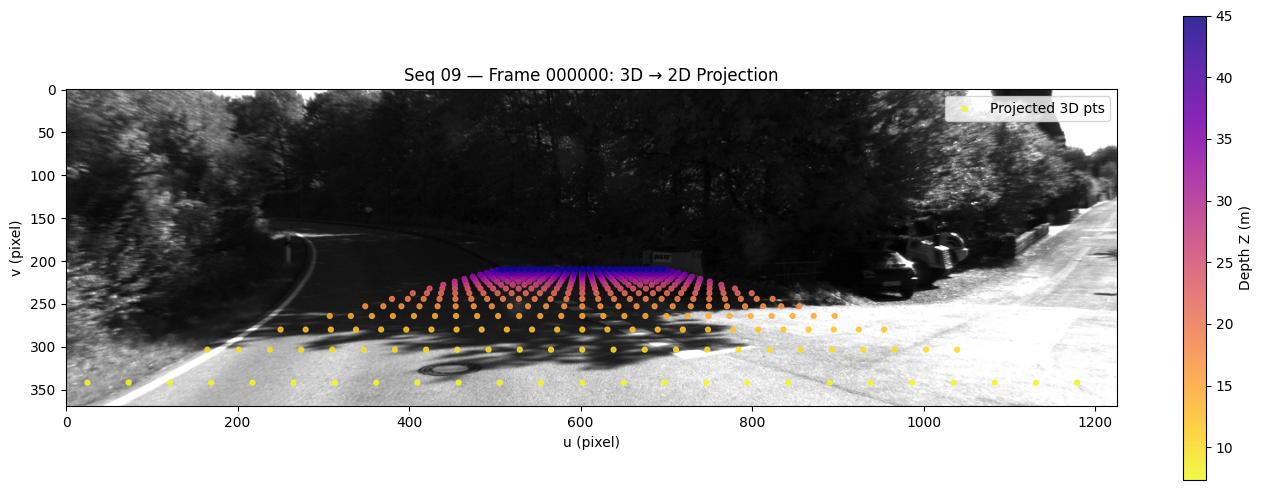

총 3D 점 수: 450
이미지 내부 투영 점 수: 425


In [48]:
def project_points(P: np.ndarray, points_3d: np.ndarray):
    # P: (3, 4), points_3d: (N, 3)
    points_hom = np.hstack([points_3d, np.ones((len(points_3d), 1))])
    img_hom = (P @ points_hom.T).T

    depth = img_hom[:, 2]
    valid = depth > 0

    uv = np.full((len(points_3d), 2), np.nan)
    uv[valid] = img_hom[valid, :2] / depth[valid, None]

    return uv, depth

# 도로 평면 위의 임의 3D 점 생성
np.random.seed(42)

x_grid = np.linspace(-6.0, 6.0, 25)   # 좌우 방향
z_grid = np.linspace(5.0, 45.0, 18)   # 전방 거리
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.full_like(X, 1.65)             # 카메라 높이 약 1.65m 아래의 도로 평면

points_3d = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
uv, depth = project_points(P0, points_3d)

mask_in = (
    (depth > 0) &
    (uv[:, 0] >= 0) & (uv[:, 0] < W) &
    (uv[:, 1] >= 0) & (uv[:, 1] < H)
)

uv_in = uv[mask_in]
z_in = points_3d[mask_in, 2]

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.imshow(first_frame, cmap="gray")
sc = ax.scatter(
    uv_in[:, 0],
    uv_in[:, 1],
    c=z_in,
    cmap="plasma_r",
    s=12,
    alpha=0.85,
    label='Projected 3D pts'
)
plt.colorbar(sc, ax=ax, label="Depth Z (m)")
ax.set_title('Seq 09 — Frame 000000: 3D → 2D Projection')
ax.set_xlabel("u (pixel)")
ax.set_ylabel("v (pixel)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(OUT_DIR / "q2_projection.png", dpi=120)
plt.show()

print(f"총 3D 점 수: {len(points_3d)}")
print(f"이미지 내부 투영 점 수: {mask_in.sum()}")

3D 점은 카메라 앞쪽 도로 평면에 있다고 가정하고 생성하였다.
$X$는 좌우 방향, $Z$는 전방 거리로 두었고, $Y$는 일정한 높이로 고정하였다.

투영 결과 가까운 점들은 이미지 아래쪽에 넓게 퍼졌고,
먼 점들은 위쪽으로 갈수록 서로 가까워졌다.
이는 원근 투영에서 깊이 $Z$가 커질수록 이미지 좌표 변화가 작아지는 현상과 일치한다.

### 해석

투영 결과, 낮은 $Z$ 값을 갖는 가까운 점들은 이미지 하단에 넓게 퍼져 나타났다. 
이는 $v = f_yY/Z + c_y$ 관계에서 $Z$가 작을수록 이미지상 위치 변화가 크게 나타나기 때문이다.

반대로 높은 $Z$ 값을 갖는 먼 점들은 이미지 중앙 또는 소실점 방향으로 모이는 경향을 보였다. 
이는 깊이가 커질수록 이미지상 변화량이 작아지는 원근 투영의 특성과 일치한다.

또한 좌우 방향 $X$에 따른 분산도 가까운 점일수록 더 크게 나타났다. 
이는 $u = f_xX/Z + c_x$ 관계에서 $Z$가 작을수록 같은 $X$ 변화가 더 큰 픽셀 이동으로 나타나기 때문이다.

따라서 Projection Matrix는 3D 점의 깊이 정보를 반영하여 2D 이미지 좌표로 변환하며, 
일부 점이 이미지 밖으로 벗어나는 것은 카메라의 시야각 범위를 벗어났기 때문이다.

---

## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 파일의 각 행은 $3 \times 4$ 변환 행렬 $T_i = [R_i \mid t_i]$로,
카메라의 월드 좌표계 내 위치 및 자세를 나타냅니다.

카메라 원점 $(0,0,0)$을 변환하면 월드 좌표에서의 위치를 구할 수 있습니다.

$$
\mathbf{p}_i = T_i \cdot [0,0,0,1]^T = t_i
$$

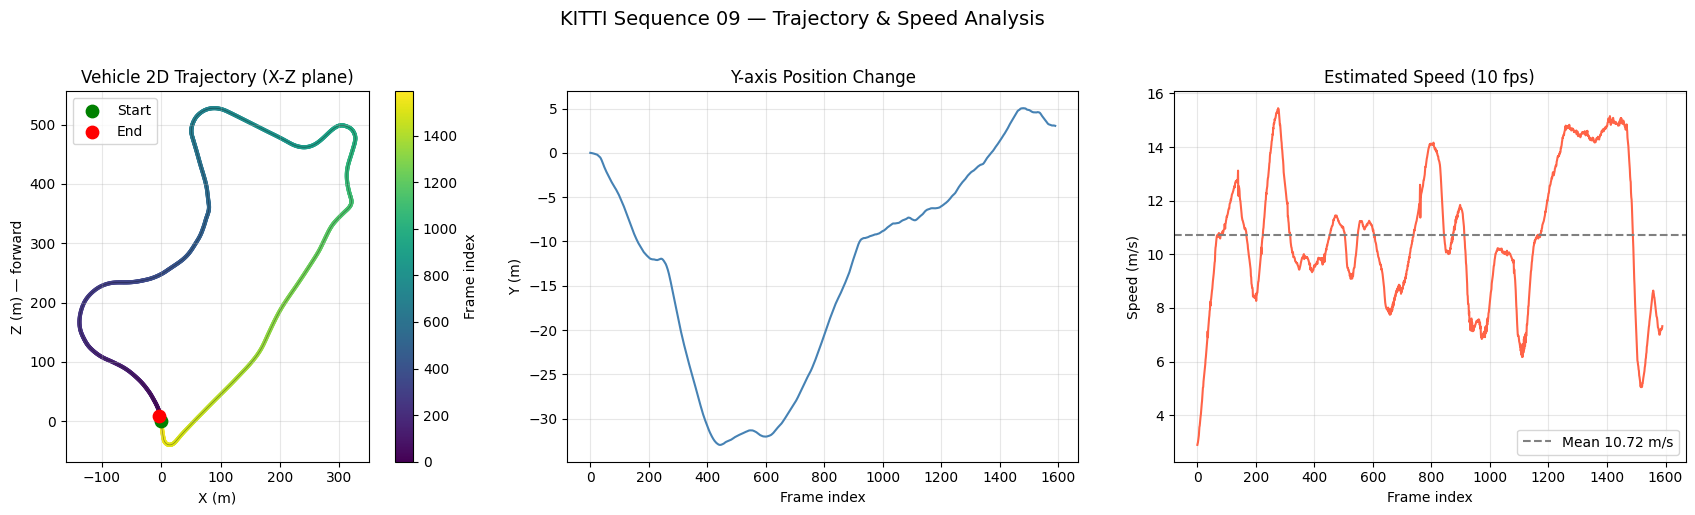

총 pose 프레임 수: 1591
총 주행 거리: 1705.1 m
평균 속도: 10.72 m/s (38.6 km/h)
최대 속도: 15.45 m/s (55.6 km/h)
최대 속도 구간: frame 276 → frame 277
전체 이동 벡터 [X, Y, Z]: [-3.006582  3.045729  8.222648]
전체 진행 방향 각도: -20.08 degrees


In [49]:
def load_poses(pose_path: Path) -> np.ndarray:
    # KITTI pose txt → (N, 3, 4) array
    poses = []
    with open(pose_path, "r") as f:
        for line in f:
            vals = np.array([float(v) for v in line.split()], dtype=np.float64).reshape(3, 4)
            poses.append(vals)
    return np.array(poses)


poses = load_poses(POSE_FILE)

# 이미지 수와 pose 수가 다를 가능성에 대비하여 공통 길이만 사용
N_pose = min(len(poses), len(frame_paths))
poses = poses[:N_pose]

# 3x4 pose를 4x4 homogeneous transformation matrix로 변환
T_all = []
for P in poses:
    T = np.eye(4)
    T[:3, :4] = P
    T_all.append(T)

T_all = np.array(T_all)

# 초기 프레임을 기준 좌표계로 설정
T0_inv = np.linalg.inv(T_all[0])
T_rel = np.array([T0_inv @ T for T in T_all])

# 각 프레임의 카메라 위치 추출
positions_rel = T_rel[:, :3, 3]

x_pos = positions_rel[:, 0]
y_pos = positions_rel[:, 1]
z_pos = positions_rel[:, 2]

# KITTI odometry는 약 10Hz로 촬영된다고 보고 속도를 근사
FPS = 10.0
diff = np.diff(positions_rel, axis=0)
dist = np.linalg.norm(diff, axis=1)
speed = dist * FPS

# 전체 이동 방향 계산
move_vec = positions_rel[-1] - positions_rel[0]
heading_angle = np.degrees(np.arctan2(move_vec[0], move_vec[2]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) X-Z 평면에서의 2D 궤적
ax = axes[0]
sc = ax.scatter(x_pos, z_pos, c=np.arange(len(x_pos)), cmap='viridis', s=4)
ax.plot(x_pos, z_pos, 'k-', lw=0.5, alpha=0.4)
ax.scatter(x_pos[0], z_pos[0], color='green', s=80, zorder=5, label='Start')
ax.scatter(x_pos[-1], z_pos[-1], color='red', s=80, zorder=5, label='End')

plt.colorbar(sc, ax=ax, label='Frame index')
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m) — forward')
ax.set_title('Vehicle 2D Trajectory (X-Z plane)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# (2) Y축 위치 변화
ax2 = axes[1]
ax2.plot(y_pos, color='steelblue')
ax2.set_xlabel('Frame index')
ax2.set_ylabel('Y (m)')
ax2.set_title('Y-axis Position Change')
ax2.grid(True, alpha=0.3)

# (3) 속도 추이
ax3 = axes[2]
ax3.plot(speed, color='tomato')
ax3.axhline(speed.mean(), ls='--', color='gray', label=f'Mean {speed.mean():.2f} m/s')
ax3.set_xlabel('Frame index')
ax3.set_ylabel('Speed (m/s)')
ax3.set_title('Estimated Speed (10 fps)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle("KITTI Sequence 09 — Trajectory & Speed Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "q3_trajectory.png", dpi=120, bbox_inches="tight")
plt.show()

total_dist = dist.sum()
max_speed_idx = speed.argmax()

print(f"총 pose 프레임 수: {N_pose}")
print(f"총 주행 거리: {total_dist:.1f} m")
print(f"평균 속도: {speed.mean():.2f} m/s ({speed.mean() * 3.6:.1f} km/h)")
print(f"최대 속도: {speed.max():.2f} m/s ({speed.max() * 3.6:.1f} km/h)")
print(f"최대 속도 구간: frame {max_speed_idx} → frame {max_speed_idx + 1}")
print(f"전체 이동 벡터 [X, Y, Z]: {move_vec}")
print(f"전체 진행 방향 각도: {heading_angle:.2f} degrees")

### 결과 해석

KITTI pose 데이터에서 각 프레임의 pose 행렬을 불러온 뒤, 이동 벡터 $t = [X, Y, Z]^T$를 추출하여 카메라의 위치를 계산하였다. 카메라는 차량에 고정되어 있으므로, 각 프레임의 카메라 위치 변화는 차량의 이동 궤적으로 해석할 수 있다.

본 실험에서는 총 **1591개의 pose 프레임**을 사용하였다. 초기 프레임을 기준 좌표계의 원점으로 설정하기 위해 첫 번째 프레임의 위치를 모든 프레임 위치에서 빼주었으며, 이를 통해 차량의 이동 궤적을 초기 위치 기준의 상대 좌표로 표현하였다.

차량의 궤적은 $X-Z$ 평면에 2D로 시각화하였다. 
왼쪽 그래프의 각 점은 하나의 프레임에서의 카메라 위치를 의미하며, 
초록색 점은 초기 프레임, 빨간색 점은 마지막 프레임을 나타낸다. 
색상은 프레임 인덱스를 의미하므로 시간이 지남에 따라 차량이 어떤 경로로 이동했는지 확인할 수 있다.
KITTI 카메라 좌표계에서 Z축은 차량의 전방 방향, X축은 좌우 방향을 의미하므로, 
X-Z 평면의 2D 궤적은 차량의 주행 경로를 위에서 내려다본 형태로 해석할 수 있다.

실험 결과, 차량의 총 주행 거리는 약 **1705.1 m**로 계산되었다. 반면 마지막 프레임의 위치는 초기 프레임을 기준으로

$
[X, Y, Z] = [-3.006582,\ 3.045729,\ 8.222648]
$

만큼 이동한 위치에 있었다. 총 주행 거리는 약 1705.1 m로 계산되었지만,시작점과 마지막 점 사이의 변위는 비교적 작게 나타났다.
이는 차량이 한 방향으로 직선 이동한 것이 아니라, 도로를 따라 회전하거나 굽은 경로를 주행했기 때문이다.

차량의 전체적인 진행 방향은 초기 위치에서 최종 위치까지의 이동 벡터를 기준으로 계산하였다. 이때 $Z$축을 전방 방향, $X$축을 좌우 방향으로 보았을 때 전체 진행 방향 각도는 약 **-20.08도**로 나타났다. 이는 최종 위치가 시작점 기준으로 전방 $Z$ 방향으로 이동하면서, 약간 왼쪽 또는 오른쪽 방향의 횡방향 변화도 함께 발생했음을 의미한다. 다만 이 각도는 전체 궤적의 시작점과 끝점을 연결한 대표 방향이므로, 주행 중간의 모든 회전 방향을 의미하지 않는다.

속도는 연속된 두 pose 사이의 위치 변화량을 이용하여 근사하였다. KITTI odometry 데이터가 약 10Hz로 수집된다고 가정하고, 프레임 간 이동 거리에 FPS를 곱하여 속도를 계산하였다.

$
v_i = |p_{i+1} - p_i| \times 10
$

계산 결과, 평균 속도는 **10.72 m/s**, 즉 약 **38.6 km/h**로 나타났고, 최대 속도는 **15.45 m/s**, 즉 약 **55.6 km/h**로 나타났다. 최대 속도는 **frame 276에서 frame 277로 이동하는 구간**에서 발생하였다. 따라서 Sequence 09에서 차량은 전반적으로 도심 주행 수준의 속도로 이동했으며, 일부 구간에서는 상대적으로 빠르게 주행한 것으로 볼 수 있다.

정리하면, pose 데이터의 이동 벡터를 이용해 차량의 위치를 프레임별로 추출할 수 있었고, 초기 프레임을 기준으로 한 상대 좌표계를 통해 차량의 전체 주행 궤적을 시각화할 수 있었다. 또한 프레임 간 위치 변화량을 이용해 차량의 속도를 근사적으로 계산함으로써, 차량의 이동 방향과 주행 속도 특성을 함께 확인할 수 있었다.


---

## 문제 4. Projection Matrix를 활용한 차선 해석


Projection Matrix P 사용
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]
fx=707.09, fy=707.09, cx=601.89, cy=183.11
Bayesian 학습 완료


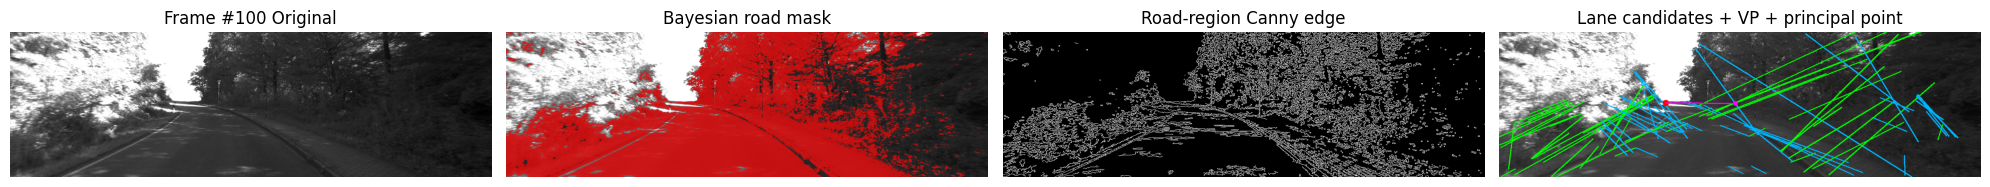

========== 문제 4 결과 ==========
분석 프레임: 100
이미지 크기: W=1226, H=370
검출된 Hough 후보선 수: 1051
필터링 후 좌측 후보선 수: 43
필터링 후 우측 후보선 수: 38
좌측 차선 평균 기울기: -0.864
우측 차선 평균 기울기: 2.080

Projection Matrix 내부 파라미터
fx=707.09
fy=707.09
cx=601.89
cy=183.11

추정 소실점: u=424.2, v=182.1
주점: cx=601.9, cy=183.1
소실점 - 주점 차이: du=-177.7, dv=-1.0
해석: 소실점의 u 좌표가 주점 cx에서 벗어나 있으므로 카메라 yaw 또는 차량 진행 방향의 틀어짐이 있을 수 있다.

Ground plane 역투영 샘플
1) image=(509.0, 216.0) → camera approx=(X=-4.66m, Y=1.65m, Z=35.47m), slope=-0.383
2) image=(320.0, 279.0) → camera approx=(X=-4.85m, Y=1.65m, Z=12.17m), slope=-0.382
3) image=(146.0, 369.0) → camera approx=(X=-4.05m, Y=1.65m, Z=6.28m), slope=-0.486
4) image=(541.0, 222.0) → camera approx=(X=-2.58m, Y=1.65m, Z=30.00m), slope=-0.382
5) image=(85.0, 323.0) → camera approx=(X=-6.10m, Y=1.65m, Z=8.34m), slope=-0.529


In [ ]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 출력 폴더
if "OUT_DIR" not in globals():
    OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ────────────────────────────────────
# 4-0. Projection Matrix 준비
# ────────────────────────────────────

def load_projection_from_calib(calib_path, key="P0"):
    calib_path = Path(calib_path)

    if not calib_path.exists():
        raise FileNotFoundError(f"calib.txt를 찾을 수 없습니다: {calib_path}")

    with open(calib_path, "r") as f:
        for line in f:
            if line.startswith(key + ":"):
                values = np.array(line.strip().split()[1:], dtype=np.float64)
                return values.reshape(3, 4)

    raise ValueError(f"{key}를 calib.txt에서 찾을 수 없습니다.")


if "P0" in globals():
    P_used = P0.copy()
else:
    calib_candidates = []

    if "calib_path" in globals():
        calib_candidates.append(Path(calib_path))

    if "SEQ_DIR" in globals():
        calib_candidates.append(Path(SEQ_DIR) / "calib.txt")

    if "seq_dir" in globals():
        calib_candidates.append(Path(seq_dir) / "calib.txt")

    calib_candidates += [
        Path("calib.txt"),
        Path("./dataset/sequences/09/calib.txt"),
        Path("./data_odometry_gray/dataset/sequences/09/calib.txt"),
    ]

    calib_file = None
    for c in calib_candidates:
        if c.exists():
            calib_file = c
            break

    if calib_file is None:
        raise FileNotFoundError("calib.txt를 찾지 못했습니다. P0를 먼저 정의하거나 calib_path를 지정하세요.")

    P_used = load_projection_from_calib(calib_file, key="P0")

fx = P_used[0, 0]
fy = P_used[1, 1]
cx = P_used[0, 2]
cy = P_used[1, 2]

print("Projection Matrix P 사용")
print(P_used)
print(f"fx={fx:.2f}, fy={fy:.2f}, cx={cx:.2f}, cy={cy:.2f}")


# ────────────────────────────────────
# 4-1. Bayesian 분류기
# ────────────────────────────────────

def get_trapezoid_mask(width, height,
                       vp_y_rate=0.55,
                       bottom_width_rate=0.85,
                       top_width_rate=0.12):
    mask = np.zeros((height, width), dtype=np.uint8)

    vp_y = int(height * vp_y_rate)

    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate / 2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate / 2)), height]

    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)

    return mask


def accumulate_histogram(img, mask):
    pixels = img[mask > 0]
    return np.bincount(pixels.flatten(), minlength=256).astype(np.float64)


def classify_frame(img, road_p, bg_p, prior_road=0.5):
    eps = 1e-10

    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))

    mask = logit > 0

    return mask.astype(np.uint8), prob


# 학습 프레임으로 road/background grayscale histogram 구축
TRAIN_N = 60
ALPHA = 0.85

sample = np.array(Image.open(frame_paths[0]).convert("L"), dtype=np.uint8)
H, W = sample.shape

road_mask_roi = get_trapezoid_mask(W, H)
bg_mask_roi = 1 - road_mask_roi

road_hist = np.ones(256)
bg_hist = np.ones(256)

for i, fp in enumerate(frame_paths[:TRAIN_N]):
    img = np.array(Image.open(fp).convert("L"), dtype=np.uint8)

    r = accumulate_histogram(img, road_mask_roi)
    b = accumulate_histogram(img, bg_mask_roi)

    if i == 0:
        road_hist = r + 1
        bg_hist = b + 1
    else:
        road_hist = ALPHA * road_hist + (1 - ALPHA) * (r + 1)
        bg_hist = ALPHA * bg_hist + (1 - ALPHA) * (b + 1)

road_p_norm = road_hist / road_hist.sum()
bg_p_norm = bg_hist / bg_hist.sum()

print("Bayesian 학습 완료")


# ────────────────────────────────────────────
# 4-2. Bayesian road mask 내부에서 차선 후보 검출
# ────────────────────────────────────────────

ANALYZE_FRAME_IDX = min(100, len(frame_paths) - 1)

img_raw = np.array(Image.open(frame_paths[ANALYZE_FRAME_IDX]).convert("L"), dtype=np.uint8)

# Bayesian road mask
road_bin, road_prob = classify_frame(img_raw, road_p_norm, bg_p_norm)

# 조명 변화 완화를 위한 CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_eq = clahe.apply(img_raw)

# 도로 영역 내부에서만 edge 검출
road_region = cv2.bitwise_and(
    img_eq,
    img_eq,
    mask=(road_bin * 255).astype(np.uint8)
)

edges = cv2.Canny(road_region, 60, 160)

# Hough line transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=25,
    minLineLength=35,
    maxLineGap=30
)

overlay_bgr = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2BGR)

# road mask overlay
mask_overlay = overlay_bgr.copy()
mask_overlay[road_bin > 0] = (
    0.35 * mask_overlay[road_bin > 0] + np.array([0, 0, 180])
).astype(np.uint8)

left_lines = []
right_lines = []


def line_from_points(x1, y1, x2, y2):
    """
    두 점을 지나는 직선 ax + by + c = 0 반환
    """
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    return np.array([a, b, c], dtype=np.float64)


if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]

        if x2 == x1:
            continue

        slope = (y2 - y1) / (x2 - x1)
        angle = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))

        # 수평선, 너무 완만한 선, 너무 위쪽의 선 제거
        if not (20 <= angle <= 160):
            continue

        if abs(slope) < 0.25:
            continue

        if max(y1, y2) < H * 0.50:
            continue

        # 이미지 좌표계에서는 y가 아래로 증가
        # 왼쪽 차선 후보: slope < 0
        # 오른쪽 차선 후보: slope > 0
        if slope < 0:
            left_lines.append((x1, y1, x2, y2, slope))
            color = (0, 255, 0)
        else:
            right_lines.append((x1, y1, x2, y2, slope))
            color = (255, 180, 0)

        cv2.line(overlay_bgr, (x1, y1), (x2, y2), color, 2)


# ────────────────────────────────────────────
# 4-3. 좌우 차선 후보선의 교점으로 소실점 추정
# ────────────────────────────────────────────

vp_candidates = []

for l in left_lines:
    for r in right_lines:
        line_l = line_from_points(l[0], l[1], l[2], l[3])
        line_r = line_from_points(r[0], r[1], r[2], r[3])

        p = np.cross(line_l, line_r)

        if abs(p[2]) > 1e-6:
            vp = p[:2] / p[2]

            # 너무 비정상적인 교점 제거
            if -W <= vp[0] <= 2 * W and 0 <= vp[1] <= H:
                vp_candidates.append(vp)

vp_est = None

if len(vp_candidates) > 0:
    vp_est = np.median(np.array(vp_candidates), axis=0)

    cv2.circle(
        overlay_bgr,
        (int(vp_est[0]), int(vp_est[1])),
        8,
        (0, 0, 255),
        -1
    )

    # 주점 표시
    cv2.circle(
        overlay_bgr,
        (int(cx), int(cy)),
        6,
        (255, 0, 255),
        -1
    )

    cv2.line(
        overlay_bgr,
        (int(cx), int(cy)),
        (int(vp_est[0]), int(vp_est[1])),
        (255, 0, 255),
        2
    )


# ────────────────────────────────────────────
# 4-4. 이미지 좌표를 ground plane 위의 카메라 좌표로 근사 역투영
# ────────────────────────────────────────────

def image_to_ground_camera(u, v, fx, fy, cx, cy, Y_ground=1.65):
    denom = v - cy

    # v가 주점보다 위쪽이면 ground plane 역투영이 불안정함
    if denom <= 1e-6:
        return None

    Z = fy * Y_ground / denom
    X = (u - cx) * Z / fx
    Y = Y_ground

    return np.array([X, Y, Z], dtype=np.float64)


ground_points = []

# 차선 선분의 아래쪽 endpoint를 ground plane 위로 역투영
for line in left_lines + right_lines:
    x1, y1, x2, y2, slope = line

    if y1 >= y2:
        u, v = x1, y1
    else:
        u, v = x2, y2

    pt3d = image_to_ground_camera(u, v, fx, fy, cx, cy, Y_ground=1.65)

    if pt3d is not None:
        ground_points.append((u, v, pt3d[0], pt3d[1], pt3d[2], slope))


# ────────────────────────────────────────────
# 4-5. 시각화
# ────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_raw, cmap="gray")
axes[0].set_title(f"Frame #{ANALYZE_FRAME_IDX} Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(mask_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title("Bayesian road mask")
axes[1].axis("off")

axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Road-region Canny edge")
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
axes[3].set_title("Lane candidates + VP + principal point")
axes[3].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "q4_lane_detection_projection.png", dpi=120)
plt.show()


# ────────────────────────────────────────────
# 4-6. 결과 출력
# ────────────────────────────────────────────

print("========== 문제 4 결과 ==========")
print(f"분석 프레임: {ANALYZE_FRAME_IDX}")
print(f"이미지 크기: W={W}, H={H}")
print(f"검출된 Hough 후보선 수: {0 if lines is None else len(lines)}")
print(f"필터링 후 좌측 후보선 수: {len(left_lines)}")
print(f"필터링 후 우측 후보선 수: {len(right_lines)}")

if len(left_lines) > 0:
    left_slopes = [l[4] for l in left_lines]
    print(f"좌측 차선 평균 기울기: {np.mean(left_slopes):.3f}")

if len(right_lines) > 0:
    right_slopes = [r[4] for r in right_lines]
    print(f"우측 차선 평균 기울기: {np.mean(right_slopes):.3f}")

print()
print("Projection Matrix 내부 파라미터")
print(f"fx={fx:.2f}")
print(f"fy={fy:.2f}")
print(f"cx={cx:.2f}")
print(f"cy={cy:.2f}")

if vp_est is not None:
    print()
    print(f"추정 소실점: u={vp_est[0]:.1f}, v={vp_est[1]:.1f}")
    print(f"주점: cx={cx:.1f}, cy={cy:.1f}")
    print(f"소실점 - 주점 차이: du={vp_est[0] - cx:.1f}, dv={vp_est[1] - cy:.1f}")

    if abs(vp_est[0] - cx) < W * 0.1:
        print("해석: 소실점의 u 좌표가 주점 cx 근처에 있으므로 차량 진행 방향과 카메라 방향이 비교적 정렬되어 있다고 볼 수 있다.")
    else:
        print("해석: 소실점의 u 좌표가 주점 cx에서 벗어나 있으므로 카메라 yaw 또는 차량 진행 방향의 틀어짐이 있을 수 있다.")

    if abs(vp_est[1] - cy) > H * 0.1:
        print("해석: 소실점의 v 좌표가 주점 cy와 차이를 보이므로 카메라 pitch 또는 도로 경사의 영향이 있을 수 있다.")
else:
    print()
    print("좌/우 차선 후보가 부족하여 소실점 추정 불가")

print()
print("Ground plane 역투영 샘플")
if len(ground_points) > 0:
    for i, item in enumerate(ground_points[:5]):
        u, v, X, Y, Z, slope = item
        print(
            f"{i+1}) image=({u:.1f}, {v:.1f}) "
            f"→ camera approx=(X={X:.2f}m, Y={Y:.2f}m, Z={Z:.2f}m), "
            f"slope={slope:.3f}"
        )
else:
    print("역투영 가능한 차선 endpoint가 부족합니다.")


Bayesian 분류 결과로 얻은 도로 영역을 관심 영역(ROI)으로 사용하고,  
그 내부에서 Canny edge와 Hough Transform을 적용하여 차선 후보선을 검출하였다.

전체 과정은 다음과 같다.

1. Bayesian 분류기로 도로 영역을 추출한다.
2. 도로 영역 내부에서만 edge를 검출한다.
3. Hough Transform으로 직선 후보를 찾는다.
4. 기울기를 기준으로 좌측 차선 후보와 우측 차선 후보를 분리한다.
5. 좌우 후보선의 교점을 이용해 소실점(vanishing point)을 추정한다.
6. 추정된 소실점과 projection matrix의 내부 파라미터를 비교하여 투영 특성을 해석한다.

---

### 1. 이미지 좌표에서 검출된 차선 후보선의 의미

검출된 차선 후보선은 이미지 좌표계의 픽셀 좌표 $(u, v)$ 위에 존재한다.  
하지만 실제로는 3D 도로 평면 위의 차선 경계가 카메라 영상 평면으로 투영된 결과이다.

Projection Matrix $P$는 3D 카메라 좌표계의 점 $(X, Y, Z)$를 이미지 좌표 $(u, v)$로 변환한다.

$$
s
\begin{bmatrix}
u \\
v \\
1
\end{bmatrix}
=
P
\begin{bmatrix}
X \\
Y \\
Z \\
1
\end{bmatrix}
$$

따라서 이미지에서 보이는 차선 후보선은 단순한 2D 선분이 아니라,  
3D 도로 구조가 projection matrix를 통해 이미지 평면에 나타난 결과로 볼 수 있다.

### 2. 도로 평면 가정과 차선의 기하적 특성

차선의 3D 의미를 해석하기 위해 도로가 하나의 평면, 즉 ground plane 위에 있다고 가정하였다.

KITTI 카메라 좌표계는 일반적으로 다음과 같이 해석할 수 있다.

- $X$: 카메라 기준 좌우 방향
- $Y$: 카메라 기준 아래쪽 방향
- $Z$: 카메라 기준 전방 방향

도로 평면을 $Y = Y_{ground}$로 두면, 이미지 좌표 $(u, v)$는 다음 관계를 통해 카메라 좌표계의 3D 위치로 근사할 수 있다.

$$
Z = \frac{f_y Y_{ground}}{v - c_y}
$$

$$
X = \frac{(u - c_x)Z}{f_x}
$$

이 식에서 $f_x$, $f_y$, $c_x$, $c_y$는 projection matrix에서 얻은 카메라 내부 파라미터이다.

이미지 하단의 차선 픽셀은 카메라에 가까운 도로 영역을 의미하고,  
이미지 위쪽 또는 소실점 근처의 차선 픽셀은 더 먼 도로 영역을 의미한다.

실제 도로 위의 좌우 차선은 거의 평행하지만, 이미지에서는 원근 투영 때문에 위쪽으로 갈수록 서로 가까워진다.  
즉, 가까운 도로 영역에서는 차선 간격이 넓게 보이고, 먼 도로 영역에서는 차선 간격이 좁게 보인다.


### 3. Projection Matrix와 소실점의 관계

3D 도로 위의 평행한 차선들은 이미지로 투영되면 한 점으로 수렴하는데, 이 점을 소실점이라고 한다.

3D 공간에서 도로 방향 벡터를 $\mathbf{d} = (d_x, d_y, d_z)$라고 하면,  
이 방향 벡터의 무한원점은 다음과 같이 표현할 수 있다.

$$
\begin{bmatrix}
d_x \\
d_y \\
d_z \\
0
\end{bmatrix}
$$

이를 projection matrix로 투영하면 이미지 위의 소실점이 된다.

$$
\tilde{\mathbf{v}}
=
P
\begin{bmatrix}
d_x \\
d_y \\
d_z \\
0
\end{bmatrix}
$$

소실점의 이미지 좌표는 다음과 같이 계산된다.

$$
u_v = \frac{\tilde{v}_1}{\tilde{v}_3},
\qquad
v_v = \frac{\tilde{v}_2}{\tilde{v}_3}
$$

따라서 소실점은 단순히 이미지에서 선분들이 만나는 점이 아니라,  
3D 도로의 진행 방향이 projection matrix에 의해 이미지 평면에 투영된 결과이다.

### 4. 결과 해석

실험 결과, Bayesian 도로 영역 안에서 Hough Transform을 적용하여 좌우 차선 후보선을 검출하였다.  
검출된 선분들은 완전한 차선이라기보다는 도로 영역 내부에서 차선으로 볼 수 있는 후보선이다.

추정된 소실점은 $(u_v, v_v) = (424.2, 182.1)$로 나타났고,  
projection matrix에서 얻은 주점은 $(c_x, c_y) = (601.9, 183.1)$이다.

소실점의 $v$ 좌표는 주점의 $c_y$와 비슷하지만,  
$u$ 좌표는 주점보다 왼쪽에 위치하였다.  
이는 해당 프레임에서 차량의 진행 방향이나 도로 방향이 카메라 중심축과 완전히 일치하지 않았기 때문으로 볼 수 있다.

또한 좌우 차선 후보선이 위쪽으로 갈수록 한 점에 가까워지는 형태를 보였는데,  
이는 실제 도로 위의 평행한 차선이 원근 투영에 의해 이미지에서 수렴해 보이는 현상과 일치한다.

### 결론

Bayesian 분류 결과로 얻은 도로 영역은 차선 후보선을 찾기 위한 ROI로 사용되었다.  
도로 영역 내부에서 검출된 차선 후보선은 실제 3D 도로 평면 위의 차선 구조가 projection matrix를 통해 2D 이미지로 투영된 결과이다.

도로를 평면으로 가정하면 이미지 좌표의 차선 픽셀을 카메라 좌표계의 3D 위치와 연결해서 해석할 수 있다.  
또한 좌우 차선 후보선의 교점으로 얻은 소실점은 도로 진행 방향이 이미지 평면에 투영된 결과이며,  
주점과의 위치 차이를 통해 차량 진행 방향, 카메라 자세, 도로 방향의 영향을 간접적으로 확인할 수 있다.


---

## 문제 5. 실패 구간 분석

Bayesian 도로 영역 분류 결과를 이용해 차선 분류가 잘 되지 않은 구간을 분석하였다.

도로 영역이 안정적으로 분류되지 않으면 이후 차선 후보 추출도 불안정해지므로, 각 프레임에서 도로로 분류된 픽셀 비율을 `road pixel ratio`로 계산하였다.  
이 값이 평균 도로 검출 비율의 60% 이하로 감소한 프레임을 실패 프레임으로 정의하고, 연속된 실패 프레임을 하나의 실패 구간으로 묶었다.

분석 대상은 이미지 프레임과 pose 기반 차량 궤적 좌표가 모두 존재하는 초기 300개 프레임으로 설정하였다.

========== 문제 5. 실패 구간 분석 ==========
분석 프레임 수: 300
평균 도로 검출 비율: 0.438
도로 검출 비율 표준편차: 0.155
실패 임계값(평균의 60%): 0.263
실패로 분류된 프레임 수: 53
실패 프레임 예시: [  0   1   2   3   4   5   6 135 136 137 138 139 140 141 142 143 164 165
 166 167]

연속 실패 구간:
1) Frame 0 ~ 6, 길이 7, 평균 road ratio = 0.206
2) Frame 135 ~ 143, 길이 9, 평균 road ratio = 0.204
3) Frame 164 ~ 200, 길이 37, 평균 road ratio = 0.189

선택한 대표 실패 구간:
Frame 164 ~ 200
대표 실패 프레임: Frame 168
궤적 상 위치: [x, z] = [-105.38, 111.66] m
대표 실패 프레임의 road ratio: 0.148


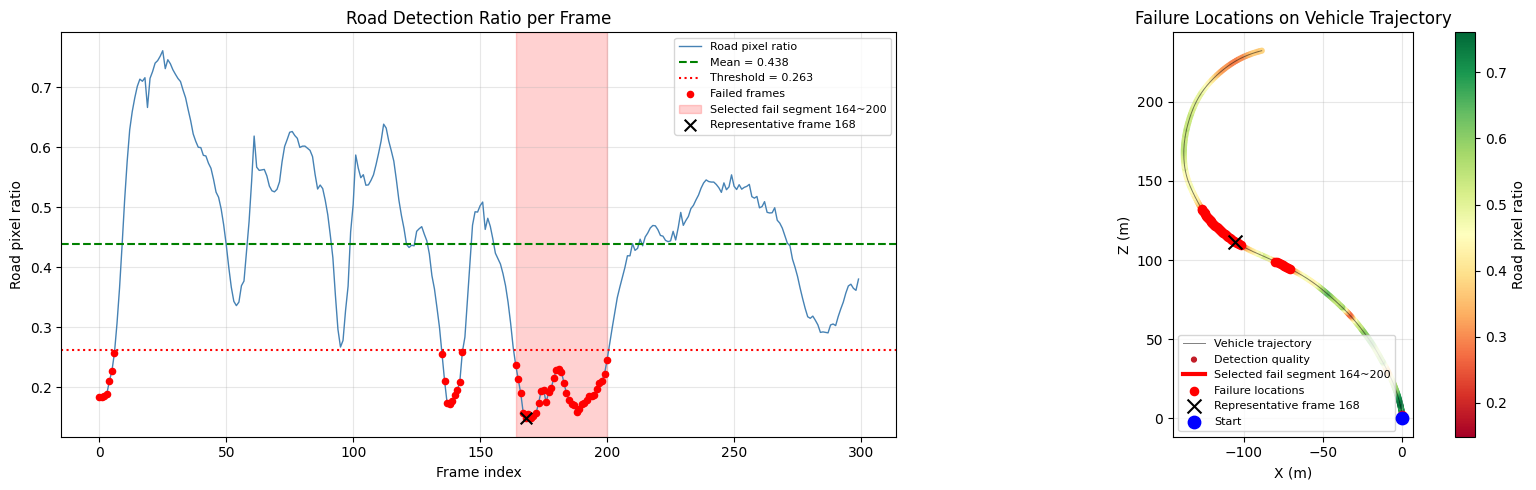

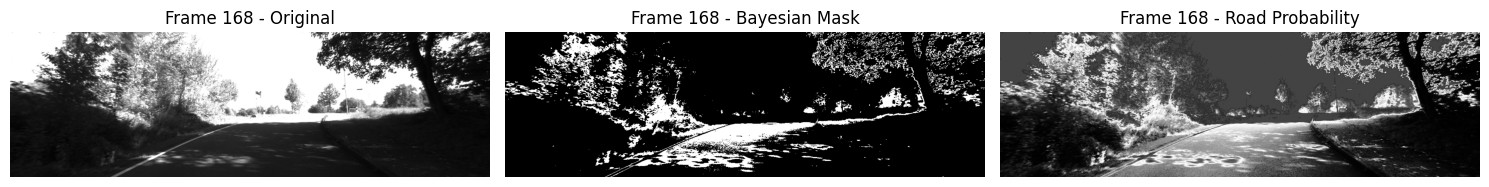

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 1. 평가할 프레임 수 설정
# ------------------------------------------------------------
EVAL_N = min(300, len(frame_paths), len(x_pos), len(z_pos))

road_ratios = []

for fp in frame_paths[:EVAL_N]:
    img = np.array(Image.open(fp).convert("L"), dtype=np.uint8)

    # Bayesian road/background 분류
    mask, prob = classify_frame(img, road_p_norm, bg_p_norm)

    # 도로로 분류된 픽셀 비율 계산
    h, w = img.shape
    ratio = mask.sum() / (h * w)
    road_ratios.append(ratio)

road_ratios = np.array(road_ratios)

mean_ratio = road_ratios.mean()
std_ratio = road_ratios.std()

# ------------------------------------------------------------
# 2. 실패 프레임 기준 설정
# ------------------------------------------------------------
# 평균 도로 검출 비율의 60% 이하-> 실패 프레임으로 판단
fail_threshold = mean_ratio * 0.6
fail_frames = np.where(road_ratios < fail_threshold)[0]

print("========== 문제 5. 실패 구간 분석 ==========")
print(f"분석 프레임 수: {EVAL_N}")
print(f"평균 도로 검출 비율: {mean_ratio:.3f}")
print(f"도로 검출 비율 표준편차: {std_ratio:.3f}")
print(f"실패 임계값(평균의 60%): {fail_threshold:.3f}")
print(f"실패로 분류된 프레임 수: {len(fail_frames)}")

if len(fail_frames) > 0:
    print(f"실패 프레임 예시: {fail_frames[:20]}")
else:
    print("임계값 이하의 실패 프레임이 없습니다.")
    print("대신 도로 검출 비율이 가장 낮은 프레임을 대표 실패 후보로 사용합니다.")


# ------------------------------------------------------------
# 3. 연속된 실패 프레임을 실패 구간으로 묶는 함수
# ------------------------------------------------------------
def group_consecutive_frames(frames):
    if len(frames) == 0:
        return []

    groups = []
    start = frames[0]
    prev = frames[0]

    for f in frames[1:]:
        if f == prev + 1:
            prev = f
        else:
            groups.append((start, prev))
            start = f
            prev = f

    groups.append((start, prev))
    return groups


fail_segments = group_consecutive_frames(fail_frames)

print("\n연속 실패 구간:")
if len(fail_segments) > 0:
    for idx, (s, e) in enumerate(fail_segments):
        seg_mean = road_ratios[s:e+1].mean()
        print(f"{idx+1}) Frame {s} ~ {e}, 길이 {e-s+1}, 평균 road ratio = {seg_mean:.3f}")
else:
    print("연속 실패 구간 없음")


# ------------------------------------------------------------
# 4. 대표 실패 구간 및 대표 실패 프레임 선택
# ------------------------------------------------------------
if len(fail_segments) > 0:
    # 구간 평균 road ratio가 가장 낮은 구간을 대표 실패 구간으로 선택
    selected_segment = min(
        fail_segments,
        key=lambda seg: road_ratios[seg[0]:seg[1] + 1].mean()
    )

    seg_start, seg_end = selected_segment

    # 대표 프레임: 선택 구간 안에서 road ratio가 가장 낮은 프레임
    segment_frames = np.arange(seg_start, seg_end + 1)
    rep_fail = segment_frames[np.argmin(road_ratios[segment_frames])]

else:
    rep_fail = int(np.argmin(road_ratios))
    seg_start, seg_end = rep_fail, rep_fail

print("\n선택한 대표 실패 구간:")
print(f"Frame {seg_start} ~ {seg_end}")
print(f"대표 실패 프레임: Frame {rep_fail}")
print(f"궤적 상 위치: [x, z] = [{x_pos[rep_fail]:.2f}, {z_pos[rep_fail]:.2f}] m")
print(f"대표 실패 프레임의 road ratio: {road_ratios[rep_fail]:.3f}")


# ------------------------------------------------------------
# 5. 도로 검출 비율 그래프 + 실패 구간 표시
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 프레임별 도로 검출 비율
ax = axes[0]

ax.plot(
    road_ratios,
    color="steelblue",
    lw=1,
    label="Road pixel ratio"
)

ax.axhline(
    mean_ratio,
    color="green",
    ls="--",
    label=f"Mean = {mean_ratio:.3f}"
)

ax.axhline(
    fail_threshold,
    color="red",
    ls=":",
    label=f"Threshold = {fail_threshold:.3f}"
)

# 전체 실패 프레임 빨간 점 표시
if len(fail_frames) > 0:
    ax.scatter(
        fail_frames,
        road_ratios[fail_frames],
        color="red",
        s=20,
        zorder=5,
        label="Failed frames"
    )

# 대표 실패 구간 음영 표시
ax.axvspan(
    seg_start,
    seg_end,
    color="red",
    alpha=0.18,
    label=f"Selected fail segment {seg_start}~{seg_end}"
)

# 대표 실패 프레임 강조
ax.scatter(
    rep_fail,
    road_ratios[rep_fail],
    color="black",
    s=70,
    marker="x",
    zorder=6,
    label=f"Representative frame {rep_fail}"
)

ax.set_xlabel("Frame index")
ax.set_ylabel("Road pixel ratio")
ax.set_title("Road Detection Ratio per Frame")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)


# (2) 차량 궤적 위에 실패 구간 표시
ax2 = axes[1]

# 전체 궤적
ax2.plot(
    x_pos[:EVAL_N],
    z_pos[:EVAL_N],
    color="black",
    lw=0.7,
    alpha=0.5,
    label="Vehicle trajectory"
)

# road ratio에 따라 색상 표시
sc = ax2.scatter(
    x_pos[:EVAL_N],
    z_pos[:EVAL_N],
    c=road_ratios,
    cmap="RdYlGn",
    s=12,
    label="Detection quality"
)

# 대표 실패 구간을 빨간 선으로 표시
ax2.plot(
    x_pos[seg_start:seg_end + 1],
    z_pos[seg_start:seg_end + 1],
    color="red",
    lw=3,
    label=f"Selected fail segment {seg_start}~{seg_end}"
)

# 실패 프레임 위치 표시
if len(fail_frames) > 0:
    ax2.scatter(
        x_pos[fail_frames],
        z_pos[fail_frames],
        color="red",
        s=35,
        zorder=5,
        label="Failure locations"
    )

# 대표 실패 프레임 강조
ax2.scatter(
    x_pos[rep_fail],
    z_pos[rep_fail],
    color="black",
    s=100,
    marker="x",
    zorder=6,
    label=f"Representative frame {rep_fail}"
)

# 시작점 표시
ax2.scatter(
    x_pos[0],
    z_pos[0],
    color="blue",
    s=80,
    zorder=6,
    label="Start"
)

ax2.set_xlabel("X (m)")
ax2.set_ylabel("Z (m)")
ax2.set_title("Failure Locations on Vehicle Trajectory")
ax2.legend(fontsize=8)
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("Road pixel ratio")

plt.tight_layout()
plt.savefig(OUT_DIR / "q5_failure_analysis.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 6. 대표 실패 프레임 원본 이미지와 Bayesian mask 비교
# ------------------------------------------------------------
img_fail = np.array(Image.open(frame_paths[rep_fail]).convert("L"), dtype=np.uint8)
mask_fail, prob_fail = classify_frame(img_fail, road_p_norm, bg_p_norm)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

axes2[0].imshow(img_fail, cmap="gray")
axes2[0].set_title(f"Frame {rep_fail} - Original")
axes2[0].axis("off")

axes2[1].imshow(mask_fail, cmap="gray")
axes2[1].set_title(f"Frame {rep_fail} - Bayesian Mask")
axes2[1].axis("off")

axes2[2].imshow(prob_fail, cmap="gray")
axes2[2].set_title(f"Frame {rep_fail} - Road Probability")
axes2[2].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "q5_failure_frame.png", dpi=150)
plt.show()

### **대표 실패 프레임:** Frame 168
대표 실패 구간은 Frame 164~200으로 선택하였다.
이 구간 중 Frame 168의 road pixel ratio가 0.148로 가장 낮게 나타났기 때문에 대표 실패 프레임으로 사용하였다.
해당 위치는 초기 프레임 기준 궤적에서 `[x, z] = [-105.38, 111.66] m` 지점이다.

Frame 168에서는 도로 위 그림자가 강하고, 도로 주변의 나무와 밝은 배경이 함께 나타난다.
Bayesian 분류기는 주로 픽셀 밝기 분포를 이용하기 때문에,
그림자로 어두워진 도로는 배경으로 빠지고, 밝은 주변 영역은 도로로 잘못 분류될 수 있다.
또한 도로가 약간 휘어지는 구간이라 고정된 사다리꼴 ROI가 실제 도로 형태를 충분히 따라가지 못했다.

#### 실패 원인

1. **조명 변화 또는 그림자**

   Frame 168에서는 도로 위에 나무 그림자가 강하게 형성되어 있다.  
   Bayesian 분류기는 픽셀 밝기 분포를 기반으로 도로와 배경을 구분하기 때문에, 도로 위 그림자가 생기면 실제 도로 영역의 밝기가 주변 배경과 비슷해진다.  
   그 결과 도로 일부가 배경으로 잘못 분류되어 mask에서 검게 빠지는 문제가 발생하였다.

2. **도로 질감 변화**

   도로 표면에는 그림자, 차선, 노면 표시, 밝은 반사 영역이 섞여 있다.  
   이 때문에 도로 픽셀의 밝기 분포가 일정하지 않고, 도로 내부에서도 밝은 부분과 어두운 부분이 크게 나뉜다.  
   단순한 밝기 기반 Bayesian 분류에서는 이러한 도로 질감 변화를 하나의 도로 영역으로 안정적으로 분류하기 어렵다.

3. **차량의 회전 또는 경사**

   원본 이미지를 보면 도로가 정면으로 곧게 뻗은 형태가 아니라 좌측으로 약간 휘어지는 구간처럼 보인다.  
   이 경우 차량의 진행 방향이 변하면서 이미지상 차선의 위치와 기울기도 함께 변한다.  
   따라서 고정된 방향의 차선 후보나 단순한 직선 도로 가정으로는 차선 영역을 안정적으로 분류하기 어렵다.

4. **ROI, 즉 사다리꼴 가정의 한계**

   본 방법은 도로가 이미지 아래쪽에서 넓고 위쪽으로 갈수록 좁아지는 고정된 사다리꼴 ROI 안에 존재한다고 가정한다.  
   그러나 Frame 168에서는 도로가 그림자와 주변 나무 영역에 의해 가려지고, 도로의 경계도 명확하지 않다.  
   또한 도로 주변의 밝은 풀, 나무, 가장자리 영역이 ROI 안에 포함되면 도로가 아닌 영역도 도로로 잘못 학습되거나 분류될 수 있다.  
   이처럼 고정된 사다리꼴 ROI는 곡선 도로, 그림자, 주변 배경이 복잡한 장면에서는 실제 도로 형태를 충분히 반영하지 못한다.

결론적으로 Frame 168의 실패는 **그림자로 인한 밝기 변화, 도로 표면의 불균일한 질감, 도로 진행 방향 변화, 고정된 사다리꼴 ROI의 한계**가 함께 작용하여 발생한 것으로 해석 한다.

---

## 문제 6. 딥러닝 기반 차선 검출 모델 제안 및 비교




총 이미지 수: 1591
첫 번째 이미지: data_odometry_gray\dataset\sequences\09\image_0\000000.png
[SELECTED MODEL] ./ufldv2_model\ufldv2_culane_res18_320x1600.onnx

[MODEL INPUT]
input [1, 3, 320, 1600] tensor(float)

[MODEL OUTPUT]
loc_row [1, 200, 72, 4] tensor(float)
loc_col [1, 100, 81, 4] tensor(float)
exist_row [1, 2, 72, 4] tensor(float)
exist_col [1, 2, 81, 4] tensor(float)

[AUTO SELECT] 후보 프레임에서 UFLDv2 검출량이 많은 프레임 탐색
frame 0000 | lanes=2 | points=87
frame 0050 | lanes=2 | points=95
frame 0100 | lanes=3 | points=119
frame 0150 | lanes=4 | points=123
frame 0168 | lanes=2 | points=37
frame 0200 | lanes=2 | points=91
frame 0250 | lanes=2 | points=58
frame 0300 | lanes=3 | points=83
frame 0350 | lanes=2 | points=99
frame 0400 | lanes=2 | points=79
frame 0500 | lanes=4 | points=147
frame 0600 | lanes=2 | points=104
frame 0700 | lanes=2 | points=60
frame 0800 | lanes=3 | points=159
frame 0900 | lanes=3 | points=118
frame 1000 | lanes=2 | points=53
frame 1100 | lanes=0 | points=0
frame 1200 | lanes

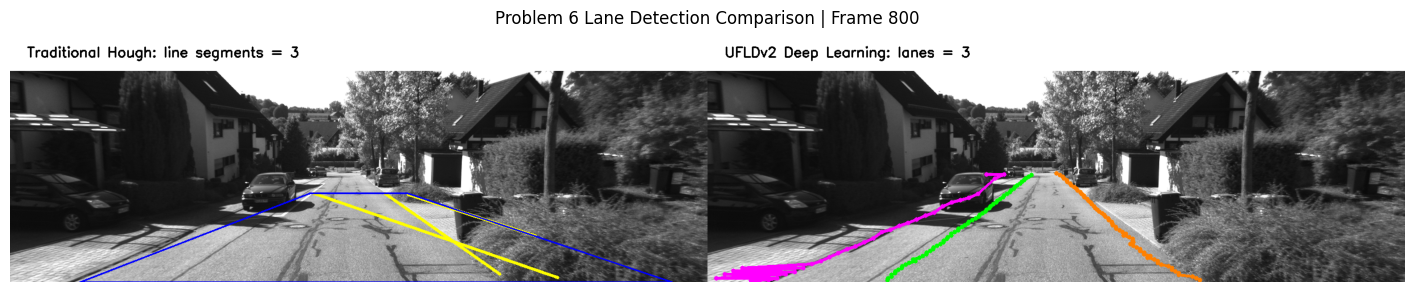

In [ ]:
import os
import glob
import sys
import tarfile
import subprocess
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0. 필요한 패키지 설치
# -----------------------------
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxruntime"], check=False)
import onnxruntime as ort


# ============================================================
# 1. 경로 설정
# ============================================================
AUTO_SELECT_FRAME = True

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))

if len(image_paths) == 0:
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {IMAGE_DIR}")

print("총 이미지 수:", len(image_paths))
print("첫 번째 이미지:", image_paths[0])


# ============================================================
# 2. UFLDv2 ONNX pretrained 모델 다운로드
# ============================================================

MODEL_DIR = "./ufldv2_model"
os.makedirs(MODEL_DIR, exist_ok=True)

TAR_PATH = os.path.join(MODEL_DIR, "resources.tar.gz")
MODEL_URL = "https://s3.ap-northeast-2.wasabisys.com/pinto-model-zoo/324_Ultra-Fast-Lane-Detection-v2/resources.tar.gz"

onnx_files = glob.glob(os.path.join(MODEL_DIR, "**", "*.onnx"), recursive=True)

if len(onnx_files) == 0:
    print("[DOWNLOAD] UFLDv2 ONNX 모델 다운로드 중...")
    
    r = requests.get(MODEL_URL, stream=True)
    r.raise_for_status()
    
    with open(TAR_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    
    print("[EXTRACT] 압축 해제 중...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(MODEL_DIR)
    
    os.remove(TAR_PATH)

onnx_files = glob.glob(os.path.join(MODEL_DIR, "**", "*.onnx"), recursive=True)

# CULane ResNet18 320x1600 모델 우선 선택
preferred = [
    f for f in onnx_files
    if "culane" in os.path.basename(f).lower()
    and "res18" in os.path.basename(f).lower()
    and "320x1600" in os.path.basename(f).lower()
]

ONNX_MODEL_PATH = preferred[0] if len(preferred) > 0 else onnx_files[0]

print("[SELECTED MODEL]", ONNX_MODEL_PATH)


# ============================================================
# 3. UFLDv2 설정 및 전처리 함수
# ============================================================

UFLD_INPUT_W = 1600
UFLD_INPUT_H = 320
CROP_RATIO = 0.6

NUM_ROW = 72
NUM_COL = 81

ROW_ANCHOR = np.linspace(0.42, 1.0, NUM_ROW)
COL_ANCHOR = np.linspace(0.0, 1.0, NUM_COL)


def softmax_np(x, axis=0):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def preprocess_ufldv2_gray(img_bgr):
    """
    KITTI grayscale image_0을 UFLDv2 입력에 맞게 변환.
    원본은 gray이지만, 모델 입력이 3채널이므로 gray 값을 3채널로 복제하여 사용
    """

    # gray 변환
    if len(img_bgr.shape) == 3:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_bgr.copy()

    # 대비 향상
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    gray_eq = clahe.apply(gray)

    # gray -> 3채널 RGB 복제
    img_rgb = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2RGB)

    # UFLDv2 입력 크기 맞추기
    resize_h = int(UFLD_INPUT_H / CROP_RATIO)
    resized = cv2.resize(
        img_rgb,
        (UFLD_INPUT_W, resize_h),
        interpolation=cv2.INTER_LINEAR
    )

    # 아래쪽 도로 영역 crop
    cropped = resized[-UFLD_INPUT_H:, :, :]

    # normalize
    x = cropped.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    x = (x - mean) / std
    x = x.transpose(2, 0, 1)          
    x = np.expand_dims(x, axis=0)     
    x = x.astype(np.float32)

    return x


# ============================================================
# 4. 기존 Hough Transform 기반 차선 검출
# ============================================================

def hough_lane_detection(img_bgr):
    """
    기존 영상처리 기반 차선 검출:
    grayscale -> CLAHE -> blur -> Canny -> ROI -> HoughLinesP
    """

    img = img_bgr.copy()
    h, w = img.shape[:2]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    gray = clahe.apply(gray)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    # 사다리꼴 ROI
    mask = np.zeros_like(edges)

    roi = np.array([[
        (int(w * 0.10), h),
        (int(w * 0.43), int(h * 0.58)),
        (int(w * 0.57), int(h * 0.58)),
        (int(w * 0.95), h)
    ]], dtype=np.int32)

    cv2.fillPoly(mask, roi, 255)
    masked_edges = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(
        masked_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=35,
        minLineLength=35,
        maxLineGap=80
    )

    vis = img.copy()
    line_count = 0

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            dx = x2 - x1
            dy = y2 - y1

            if dx == 0:
                continue

            slope = dy / dx

            # 너무 수평인 선 제거
            if abs(slope) < 0.25:
                continue

            # Hough 결과: 노란색
            cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 255), 3)
            line_count += 1

    # ROI 표시: 파란색
    cv2.polylines(vis, roi, isClosed=True, color=(255, 0, 0), thickness=2)

    return vis, line_count


# ============================================================
# 5. UFLDv2 후처리 및 시각화 함수
# ============================================================

def pred2coords_ufldv2(
    loc_row,
    loc_col,
    exist_row,
    exist_col,
    img_w,
    img_h,
    conf_th=0.12,
    min_points=3,
    local_width=1
):
    """
    UFLDv2 출력값을 이미지 좌표로 변환.
    gray 이미지라 검출이 약할 수 있으므로 conf_th를 낮게 설정.
    """

    loc_row_prob = softmax_np(loc_row, axis=1)
    loc_col_prob = softmax_np(loc_col, axis=1)

    # class 1 = 차선 존재 확률
    exist_row_prob = softmax_np(exist_row, axis=1)[0, 1, :, :]
    exist_col_prob = softmax_np(exist_col, axis=1)[0, 1, :, :]

    lanes = []

    num_grid_row = loc_row.shape[1]
    num_grid_col = loc_col.shape[1]

    # UFLDv2 CULane 기준
    row_lane_idx = [1, 2]
    col_lane_idx = [0, 3]

    # 중앙 차선 후보: row anchor 기반
    for lane_idx in row_lane_idx:
        pts = []

        for k in range(NUM_ROW):
            exist_conf = exist_row_prob[k, lane_idx]

            if exist_conf >= conf_th:
                center = int(np.argmax(loc_row_prob[0, :, k, lane_idx]))

                left = max(0, center - local_width)
                right = min(num_grid_row - 1, center + local_width)
                inds = np.arange(left, right + 1)

                prob = loc_row_prob[0, inds, k, lane_idx]
                x_pos = np.sum(prob * inds) / (np.sum(prob) + 1e-6) + 0.5

                x = x_pos / (num_grid_row - 1) * img_w
                y = ROW_ANCHOR[k] * img_h

                if 0 <= x < img_w and 0 <= y < img_h:
                    pts.append((int(x), int(y)))

        if len(pts) >= min_points:
            lanes.append(pts)

    # 바깥 차선 후보: col anchor 기반
    for lane_idx in col_lane_idx:
        pts = []

        for k in range(NUM_COL):
            exist_conf = exist_col_prob[k, lane_idx]

            if exist_conf >= conf_th:
                center = int(np.argmax(loc_col_prob[0, :, k, lane_idx]))

                left = max(0, center - local_width)
                right = min(num_grid_col - 1, center + local_width)
                inds = np.arange(left, right + 1)

                prob = loc_col_prob[0, inds, k, lane_idx]
                y_pos = np.sum(prob * inds) / (np.sum(prob) + 1e-6) + 0.5

                x = COL_ANCHOR[k] * img_w
                y = y_pos / (num_grid_col - 1) * img_h

                if 0 <= x < img_w and 0 <= y < img_h:
                    pts.append((int(x), int(y)))

        if len(pts) >= min_points:
            lanes.append(pts)

    return lanes


def draw_lanes(img_bgr, lanes):
    vis = img_bgr.copy()

    colors = [
        (0, 255, 0),      # green
        (0, 128, 255),    # orange
        (255, 0, 255),    # magenta
        (255, 0, 0)       # blue
    ]

    for lane_idx, lane in enumerate(lanes):
        color = colors[lane_idx % len(colors)]

        lane_sorted = sorted(lane, key=lambda p: p[1])
        pts = np.array(lane_sorted, dtype=np.int32)

        for x, y in pts:
            cv2.circle(vis, (x, y), 4, color, -1)

        if len(pts) >= 2:
            cv2.polylines(vis, [pts], isClosed=False, color=color, thickness=3)

    return vis


def run_ufldv2(img_bgr, session, conf_th=0.12):
    input_name = session.get_inputs()[0].name

    x = preprocess_ufldv2_gray(img_bgr)

    raw_outputs = session.run(None, {input_name: x})
    output_names = [o.name for o in session.get_outputs()]
    out = {name: value for name, value in zip(output_names, raw_outputs)}

    loc_row = out["loc_row"]
    loc_col = out["loc_col"]
    exist_row = out["exist_row"]
    exist_col = out["exist_col"]

    h, w = img_bgr.shape[:2]

    lanes = pred2coords_ufldv2(
        loc_row,
        loc_col,
        exist_row,
        exist_col,
        img_w=w,
        img_h=h,
        conf_th=conf_th,
        min_points=3
    )

    vis = draw_lanes(img_bgr, lanes)

    return vis, lanes


# ============================================================
# 6. 모델 로드 확인
# ============================================================

session = ort.InferenceSession(
    ONNX_MODEL_PATH,
    providers=["CPUExecutionProvider"]
)

print("\n[MODEL INPUT]")
for inp in session.get_inputs():
    print(inp.name, inp.shape, inp.type)

print("\n[MODEL OUTPUT]")
for out in session.get_outputs():
    print(out.name, out.shape, out.type)


# ============================================================
# 7. 사용할 프레임 선택
# ============================================================

if AUTO_SELECT_FRAME:
    print("\n[AUTO SELECT] 후보 프레임에서 UFLDv2 검출량이 많은 프레임 탐색")

    candidate_frames = [
        0, 50, 100, 150, 168, 200, 250, 300, 350, 400,
        500, 600, 700, 800, 900, 1000, 1100, 1200, 1300,
        1400, 1500
    ]

    results = []

    for idx in candidate_frames:
        if idx >= len(image_paths):
            continue

        img_tmp = cv2.imread(image_paths[idx], cv2.IMREAD_COLOR)

        if img_tmp is None:
            continue

        ufld_tmp, lanes_tmp = run_ufldv2(
            img_tmp,
            session,
            conf_th=0.12
        )

        lane_count = len(lanes_tmp)
        point_count = sum(len(lane) for lane in lanes_tmp)

        results.append((idx, lane_count, point_count))

        print(f"frame {idx:04d} | lanes={lane_count} | points={point_count}")

    results = sorted(results, key=lambda x: x[2], reverse=True)

    FRAME_IDX = results[0][0]

    print("\n[SELECTED FRAME]", FRAME_IDX)

else:
    print("\n[MANUAL FRAME]", FRAME_IDX)


# ============================================================
# 8. 최종 비교 결과 생성
# ============================================================

img_path = image_paths[FRAME_IDX]
img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise FileNotFoundError(img_path)

# 기존 Hough 결과
hough_vis, hough_line_count = hough_lane_detection(img_bgr)

# 딥러닝 UFLDv2 결과
ufld_vis, ufld_lanes = run_ufldv2(
    img_bgr,
    session,
    conf_th=0.12
)

print("\n[FINAL RESULT]")
print("Frame:", FRAME_IDX)
print("Hough line segments:", hough_line_count)
print("UFLDv2 lanes:", len(ufld_lanes))
print("UFLDv2 point counts:", [len(lane) for lane in ufld_lanes])


# ============================================================
# 9. 결과 시각화
# ============================================================

h, w = img_bgr.shape[:2]

comparison = np.hstack([hough_vis, ufld_vis])

title_h = 70
canvas = np.ones((h + title_h, w * 2, 3), dtype=np.uint8) * 255
canvas[title_h:, :, :] = comparison

cv2.putText(
    canvas,
    f"Traditional Hough: line segments = {hough_line_count}",
    (30, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 0),
    2
)

cv2.putText(
    canvas,
    f"UFLDv2 Deep Learning: lanes = {len(ufld_lanes)}",
    (w + 30, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 0),
    2
)

save_path = f"problem6_lane_comparison_frame_{FRAME_IDX:06d}.png"
cv2.imwrite(save_path, canvas)

plt.figure(figsize=(18, 6))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"Problem 6 Lane Detection Comparison | Frame {FRAME_IDX}")
plt.axis("off")
plt.show()


## 문제 6. 딥러닝 기반 차선 검출 모델 제안 및 비교

기존 Bayesian 기반 방법은 픽셀 밝기 분포와 사다리꼴 ROI를 이용하여 도로 영역을 분류한 뒤,  
그 영역 안에서 edge와 Hough Transform을 적용하여 차선 후보선을 찾는 방식이다.

이 방법은 구조가 단순하고 projection matrix와 연결하여 해석하기 쉽다는 장점이 있다.  
하지만 조명 변화, 그림자, 도로 질감 변화, 곡선 도로에서는 도로 영역 분류가 불안정해지고,  
그 결과 차선 후보선도 많이 흔들리는 한계가 있었다.

이를 보완하기 위해 딥러닝 기반 차선 검출 모델로  
UFLDv2(Ultra Fast Lane Detection v2)를 적용하였다.

UFLDv2는 전체 이미지를 픽셀 단위로 segmentation하는 방식이 아니라,  
차선이 존재할 가능성이 높은 위치를 row/column anchor 기준으로 예측하는 모델이다.  
따라서 비교적 빠르게 동작하면서도 차선의 전체적인 형태를 학습하여 검출할 수 있다.

이번 실험에서는 CULane 데이터셋으로 학습된 pretrained ONNX 모델을 사용하였다.

- 사용 모델: `ufldv2_culane_res18_320x1600.onnx`
- 입력 크기: `[1, 3, 320, 1600]`
- 사용 데이터: KITTI Odometry Sequence 09 `image_0`
- 전체 프레임 수: 1591장

---

### 1. Bayesian/Hough 방식과 UFLDv2 방식 비교

Bayesian/Hough 방식은 먼저 도로 영역을 추정한 뒤,  
그 내부에서 edge와 직선 성분을 찾아 차선 후보선을 검출한다.  
따라서 도로와 배경의 밝기 차이가 뚜렷한 구간에서는 어느 정도 차선 후보선을 찾을 수 있었다.

하지만 이 방식은 픽셀 밝기와 ROI 가정에 많이 의존한다.  
그림자나 도로 질감 변화가 있는 경우 도로 영역이 배경으로 잘못 분류될 수 있고,  
도로가 아닌 영역에서도 edge가 검출되어 차선 후보선이 과도하게 많이 나타날 수 있다.

반면 UFLDv2는 학습된 차선 형태를 바탕으로 차선을 검출한다.  
단순히 밝기값만 비교하는 것이 아니라, 차선이 나타나는 위치와 형태를 모델이 학습했기 때문에  
일부 프레임에서는 기존 방식보다 더 정리된 차선 검출 결과를 보였다.

### 2. 적용 결과 해석

대표 비교 프레임은 후보 프레임들 중 UFLDv2의 검출 point 수가 가장 많은 프레임으로 선택하였다.  
따라서 이 결과는 전체 sequence에 대한 정량 평가라기보다는,  
pretrained 딥러닝 모델을 KITTI 영상에 적용했을 때의 대표적인 비교를 했다.

실험 결과, 기존 Hough 기반 방식에서는 여러 개의 직선 후보가 동시에 검출되었다.  
이 중 일부는 실제 차선과 관련이 있지만, 도로 경계나 그림자, 노면의 edge도 함께 검출되어  
결과가 다소 복잡하게 나타났다.

반면 UFLDv2는 차선을 하나의 선 형태로 출력하여  
기존 방식보다 시각적으로 더 정리된 결과를 보였다.  
특히 차선의 전체적인 진행 방향을 비교적 잘 따라가는 모습을 확인할 수 있었다.

이는 UFLDv2가 단순한 픽셀 밝기 차이가 아니라  
차선의 위치와 형태적 특징을 학습한 모델이기 때문으로 볼 수 있다.


### 3. 한계 및 개선 방향

이번 실험에서 사용한 UFLDv2 모델은 CULane 데이터셋으로 학습된 pretrained 모델이다.  
따라서 KITTI Sequence 09의 카메라 시점, 도로 환경, 차선 형태에 완전히 최적화된 모델은 아니다.

또한 KITTI `image_0`은 grayscale 영상이기 때문에,  
모델 입력에 맞추기 위해 gray 이미지를 3채널로 복제하여 사용하였다.  
이 과정에서 실제 RGB 영상에 비해 색상 정보가 부족하므로 검출 성능이 제한될 수 있다.

따라서 일부 프레임에서는 차선 검출이 불안정할 가능성이 있으며,  
더 안정적인 결과를 얻기 위해서는 KITTI 데이터에 맞춘 fine-tuning이 필요하다.  
추후에는 KITTI Sequence 09의 일부 프레임에 차선 라벨을 직접 만들고,  
이를 이용해 UFLDv2를 추가 학습시키는 방식으로 개선할 수 있다.


### 결론

Bayesian/Hough 기반 방법은 구현이 단순하고 projection matrix와 연결하여 해석하기 쉽다는 장점이 있었다.  
하지만 조명 변화, 그림자, 도로 질감 변화에 민감하여 차선 후보선이 불안정하게 검출되는 한계가 있었다.

UFLDv2는 학습된 차선 형태를 이용하기 때문에 기존 방식보다 더 정리된 차선 검출 결과를 보였다.  
다만 pretrained 모델을 그대로 사용했기 때문에 KITTI Sequence 09의 모든 상황에 완전히 맞지는 않았고,  
더 안정적인 차선 검출을 위해서는 KITTI 환경에 맞춘 fine-tuning이 필요하다고 판단하였다.